In [1]:
from data_generation import Environment
from eswm import ESWM,get_batch,OpenWorld,accuracy,RandomWall,get_variable_batches,rw_accuracy,masked_prediction
import torch
import pandas as pd
import seaborn as sns

In [2]:
open_arena = Environment()
random_wall= Environment(side_length=4,add_wall=True,hidden=5,possible_states=37,query_all=True)
open_embed = OpenWorld()
random_embed = RandomWall()

In [6]:
model=ESWM(open_embed,num_layers=6)
state_dict = torch.load('tests/open.pth', map_location='cpu', weights_only=True)
model.load_state_dict(state_dict['model_state_dict'])
#x,y,padding_mask,query_mask = get_variable_batches(random_wall,batch_size=100,test=False,state_bins=False)
x,y,padding_mask,query_mask = get_batch(open_arena,1000,test=True)
model.to(torch.device('cpu'))
model.eval()
output= model(x,padding_mask)

#mask =[query_mask[:,0:1].repeat(1,6),query_mask[:,1:2].repeat(1,6),query_mask[:,2:].repeat(1,6)]
#p = [torch.masked_select(output[i], mask[i]).view(-1,output[i].shape[1]) for i in range(3)]
#t = [torch.masked_select(y[i], mask[i][]) for i in range(3)]

#acc = rw_accuracy(p,t)
acc=masked_prediction(query_mask,output,y,True)
print('masked prediction accuracy',*acc)
print('all state accucracy',*masked_prediction(query_mask,output,y,True,True))

masked prediction accuracy tensor(0.0278) tensor(0.4261) tensor(0.0247)
all state accucracy tensor(0.6850) tensor(0.7980) tensor(0.6840)


In [3]:
model=ESWM(random_embed,num_layers=4,input_dim=1024,state_dim=38,num_actions=7)
state_dict = torch.load('l4_test2.pth', map_location='cpu', weights_only=True)
model.load_state_dict(state_dict)
x,y,padding_mask,query_mask = get_variable_batches(random_wall,batch_size=100,test=False,state_bins=False)
#x,y,padding_mask,query_mask = get_batch(env,1000,False)
model.to(torch.device('cpu'))
model.eval()
output= model(x,padding_mask,query_mask)

mask =[query_mask[:,0:1].repeat(1,38),query_mask[:,1:2].repeat(1,7),query_mask[:,2:].repeat(1,38)]
p = [torch.masked_select(output[i], mask[i]).view(-1,output[i].shape[1]) for i in range(3)]
t = [torch.masked_select(y[i], mask[i][:,0]) for i in range(3)]

#acc = rw_accuracy(p,t)
acc=masked_prediction(query_mask,output,y,False)
print('masked prediction accuracy',*acc)
print('all state accucracy',*masked_prediction(query_mask,output,y,False,True))

masked prediction accuracy tensor(0.6786) tensor(0.8710) tensor(0.7317)
all state accucracy tensor(0.9100) tensor(0.9600) tensor(0.8900)


In [ ]:
target=torch.cat(y,dim=1)
out = [o[:1360] for o in output]
masked_prediction(query_mask[:1360],out,target[:1360],state_bins=False)

In [ ]:
target=torch.cat(y,dim=1)
out = [o[1360:1660] for o in output]
masked_prediction(query_mask[1360:1660],out,target[1360:1660],state_bins=False)

tensor([0.8352, 0.8817, 0.9655])

In [ ]:
target=torch.cat(y,dim=1)
out = [o[1660:] for o in output]
masked_prediction(query_mask[1660:],out,target[1660:],state_bins=False)

tensor([0.8968, 0.9300, 0.8246])

(0.0, 200000.0)

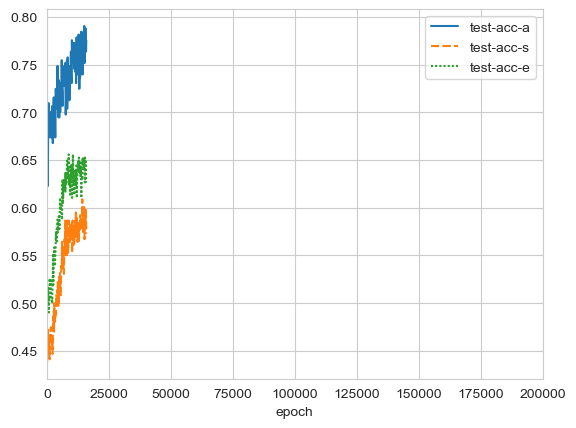

In [ ]:
data = pd.read_csv('l4_test1.csv')
data = data.set_index('epoch')
#data['index'] = [i for i in range(800)]
sns.set_style('whitegrid')
ax=sns.lineplot(data[['test-acc-a','test-acc-s','test-acc-e',]])#'train-acc-a','train-acc-s','train-acc-e']])
ax.set_xlim(0,200000)

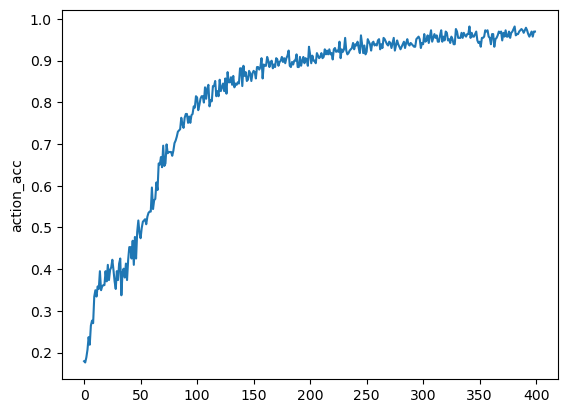

In [ ]:
data = pd.read_csv('tests/tester3.csv')
#data['index'] = [i for i in range(800)]

ax=sns.lineplot(data['action_acc'])#.rolling(10,center=True).mean(),)

